In [1]:
# Core
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("aqi cat.csv").dropna()

def get_aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    return "Hazardous"

df["AQI_Category"] = df["aqi value"].apply(get_aqi_category)

features = ['dhtTemp', 'dhthum', 'LDR value', 'rainValue', 'pressure', 'altitude', 'rainStatusNum']
X, y = df[features], df["AQI_Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Decision Tree - AQI Category Classification")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Decision Tree - AQI Category Classification
Accuracy: 0.6071

Confusion Matrix:
 [[ 5  0  2  0  1  0]
 [ 0 28  0  1  0  3]
 [ 1  0  7  1  1  0]
 [ 1  2  0  1  3  3]
 [ 0  1  3  2  3  1]
 [ 0  3  1  1  2  7]]

Classification Report:
                                 precision    recall  f1-score   support

                          Good       0.71      0.62      0.67         8
                     Hazardous       0.82      0.88      0.85        32
                      Moderate       0.54      0.70      0.61        10
                     Unhealthy       0.17      0.10      0.12        10
Unhealthy for Sensitive Groups       0.30      0.30      0.30        10
                Very Unhealthy       0.50      0.50      0.50        14

                      accuracy                           0.61        84
                     macro avg       0.51      0.52      0.51        84
                  weighted avg       0.58      0.61      0.59        84



In [3]:
df = pd.read_csv("aqi cat.csv").dropna()

def get_aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    return "Hazardous"

df["AQI_Category"] = df["aqi value"].apply(get_aqi_category)

label_encoder = LabelEncoder()
df["AQI_Label"] = label_encoder.fit_transform(df["AQI_Category"])

features = ['dhtTemp', 'dhthum', 'LDR value', 'pressure', 'altitude', 'rainValue']
X, y = df[features], df["AQI_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(
    y_test, y_pred, target_names=label_encoder.classes_
)

coef_df = pd.DataFrame(
    model.coef_.T,
    index=features,
    columns=[f"Class {cls}" for cls in label_encoder.classes_]
)

print("Logistic Regression - AQI Category Classification")
print(f"Accuracy: {accuracy:.4f}\n")
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)
print("\nLogistic Coefficients:\n", coef_df)
print("\nIntercepts:\n", model.intercept_)

Logistic Regression - AQI Category Classification
Accuracy: 0.5119

Confusion Matrix:
 [[ 2  0  1  3  0  1]
 [ 0 31  1  0  0  1]
 [ 1  0  2  1  4  1]
 [ 1  6  0  0  1  1]
 [ 1  5  0  3  4  0]
 [ 0  6  1  1  1  4]]

Classification Report:
                                 precision    recall  f1-score   support

                          Good       0.40      0.29      0.33         7
                     Hazardous       0.65      0.94      0.77        33
                      Moderate       0.40      0.22      0.29         9
                     Unhealthy       0.00      0.00      0.00         9
Unhealthy for Sensitive Groups       0.40      0.31      0.35        13
                Very Unhealthy       0.50      0.31      0.38        13

                      accuracy                           0.51        84
                     macro avg       0.39      0.34      0.35        84
                  weighted avg       0.47      0.51      0.47        84


Logistic Coefficients:
            Cl

In [4]:
df = pd.read_csv("aqi cat.csv").dropna()

def get_aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    return "Hazardous"

df["AQI_Category"] = df["aqi value"].apply(get_aqi_category)

label_encoder = LabelEncoder()
df["AQI_Label"] = label_encoder.fit_transform(df["AQI_Category"])

features = ['dhtTemp', 'dhthum', 'LDR value', 'pressure', 'altitude', 'rainValue']
X, y = df[features], df["AQI_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss")
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("XGBoost - AQI Category Classification")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=label_encoder.classes_))

XGBoost - AQI Category Classification
Accuracy: 0.6905

Confusion Matrix:
 [[ 5  0  1  1  0  0]
 [ 0 31  0  0  0  2]
 [ 2  0  5  1  1  0]
 [ 0  3  0  2  1  3]
 [ 0  1  2  3  6  1]
 [ 0  3  0  1  0  9]]

Classification Report:
                                 precision    recall  f1-score   support

                          Good       0.71      0.71      0.71         7
                     Hazardous       0.82      0.94      0.87        33
                      Moderate       0.62      0.56      0.59         9
                     Unhealthy       0.25      0.22      0.24         9
Unhealthy for Sensitive Groups       0.75      0.46      0.57        13
                Very Unhealthy       0.60      0.69      0.64        13

                      accuracy                           0.69        84
                     macro avg       0.63      0.60      0.60        84
                  weighted avg       0.68      0.69      0.68        84



/home/banibrata/miniconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [22:30:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/tmp/ipykernel_56651/2376149889.py:4: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1000x600 with 0 Axes>

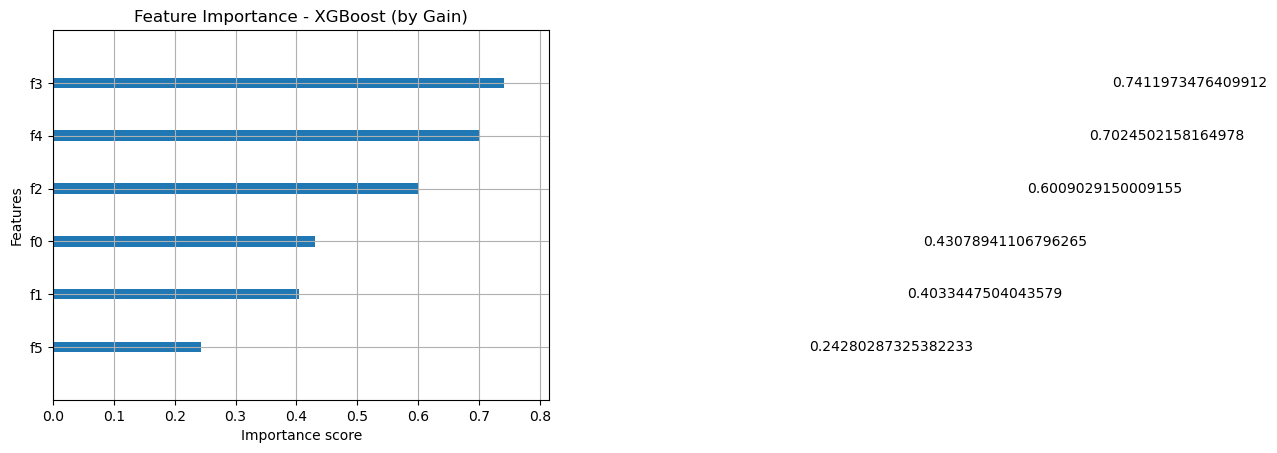

In [5]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type="gain")
plt.title("Feature Importance - XGBoost (by Gain)")
plt.tight_layout()
plt.show()